# Finding the invisible: $W\to\mu\nu$ from truth to missing momentum

The electron, its heavier relatives the muon and tau, and their neutrinos and antiparticles belong to a family of particles called **leptons**. The W boson is a carrier of the weak interaction and can decay into a charged lepton and a neutrino.

In a decay such as $Z\to\mu^+\mu^-$, the detector can reconstruct both muons and combine their momenta to infer the mass of the parent Z boson. A $W\to\mu\nu$ decay poses a more challenging question:

> **How can we learn about a particle when one of its decay products crosses the detector unseen?**

We will use one file from the CMS simulated [W+jets NanoAOD dataset](https://opendata.cern.ch/record/cms-69747). NanoAOD is a compact event format: each entry represents one collision event, and its named columns (called **branches**) store simulated and reconstructed quantities. Simulation lets us look at generator “truth,” then compare it with what CMS reconstructs.

This is the main conceptual lesson. No previous particle-physics or Python experience is required. If Python is new to you, run the code as written and focus on the questions, tables, and plots; cells labelled **Toolbox** contain reusable machinery and may be treated as black boxes. If you want a short coding warm-up first, use [Explore CERN Open Data record 69747](explore_69747.ipynb).

## Learning goals

By the end, you should be able to:

- distinguish a physics diagram, a simulated particle record, and detector reconstruction;
- describe how energy and momentum form a four-vector and what transverse momentum $p_T$ measures;
- connect a generated muon to a reconstructed muon and interpret $\Delta R$;
- explain why missing transverse momentum is an inferred vector, not a detected neutrino;
- explain why the neutrino's unknown longitudinal momentum prevents full invariant-mass reconstruction; and
- construct the transverse mass $m_T$ of the $W$ candidate.

The lesson follows one question through several stages:

$$\text{generated W decay}\longrightarrow\text{reconstructed muon}\longrightarrow\text{momentum imbalance}\longrightarrow m_T.$$

Cells labelled **Toolbox** contain machinery needed for the lesson. Run them, but do not worry about every line on a first pass.

## 1. Setup

The setup cell installs any missing Python packages, then opens the ROOT file directly from CERN Open Data through XRootD. Uproot reads only the requested parts of the remote file, so no 133 MB download is needed. The cell is safe to run more than once.

In [20]:
# @title Setup: install missing packages and open the remote ROOT file
import importlib.util
import subprocess
import sys

# Install only dependencies that are missing from the current environment.
required_packages = {
    "awkward": "awkward==2.12.0",
    "uproot": "uproot==5.7.5",
    "XRootD": "xrootd==6.1.0",
    "fsspec_xrootd": "fsspec-xrootd==0.5.5",
    "vector": "vector==1.8.1",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from IPython.display import Markdown, display

file_url = (
    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/"
    "WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/NANOAODSIM/"
    "106X_mcRun2_asymptotic_v17-v1/270000/"
    "00702195-E707-3743-8BBA-57EB9DEE1DBA.root"
)
root_file = uproot.open(file_url)
events = root_file["Events"]
print(f"Uproot {uproot.__version__}; Awkward {ak.__version__}")
print("Input: CERN Open Data via XRootD")
print(f"URL: {file_url}")
print(f"Events: {events.num_entries:,}")

Uproot 5.7.5; Awkward 2.12.0
Input: CERN Open Data via XRootD
URL: root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/00702195-E707-3743-8BBA-57EB9DEE1DBA.root
Events: 133,692


## 2. From a physics picture to stored particles

In particle physics, we use **Feynman diagrams** to represent particle interactions. The diagrams below show examples of producing a W together with an outgoing quark, followed by W boson decay. Quarks and gluons are collectively called **partons**; an outgoing parton can later develop into a **jet**, a narrow spray of particles. Read the diagrams from left to right: straight lines represent quarks or leptons, the curly line a gluon, and the wavy line a W boson.

These diagrams are useful illustrations, but they are not photographs or complete event histories. Several diagrams can contribute to the same process, and a simulated event contains additional particles and interactions that are not shown here.

In [21]:
# @title Representative W production and decay diagrams
from IPython.display import HTML

diagram_base = "https://atlas.physicsmasterclasses.org/wpath_files/img/Feynman"
diagram_cards = [
    ("u + g → d + W⁺ (one-parton example)", f"{diagram_base}/WplusDown.png"),
    ("W⁺ → μ⁺ + νμ", f"{diagram_base}/Wplus_Antimyon.png"),
    ("d + g → u + W⁻ (one-parton example)", f"{diagram_base}/WminusUp.png"),
    ("W⁻ → μ⁻ + ν̄μ", f"{diagram_base}/Wminus_Myon.png"),
]
cards_html = "".join(
    f"<figure style='margin:0;text-align:center'><img src='{url}' alt='{caption}' "
    f"style='width:100%;max-height:260px;object-fit:contain'><figcaption>{caption}</figcaption></figure>"
    for caption, url in diagram_cards
)
HTML(
    f"<div style='display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:18px'>{cards_html}</div>"
    "<p style='font-size:0.85em;color:#475569'>Source and image credit: "
    "<a href='https://atlas.physicsmasterclasses.org/en/wpath_lhcphysics2.htm'>ATLAS W-Path, "
    "International Physics Masterclasses</a>. See the "
    "<a href='https://ippog.org/ippog-copyright'>IPPOG educational-use terms</a>.</p>"
)

| View | What it represents |
| --- | --- |
| Feynman diagram | A simplified drawing used when calculating a particle interaction; it is not a complete event record |
| `LHEPart` | The incoming and outgoing particles in the primary high-energy interaction |
| `GenPart` | A selected history after later generator steps and decays; repeated copies of one particle may appear |

The names `LHEPart` and `GenPart` refer to two collections of stored simulation information, not to two new kinds of particle. Notice that a W drawn in a diagram need not appear as its own `LHEPart` row. A diagram illustrates a calculation, while an event record stores selected stages of a simulation. The [branch documentation for this exact file](https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAODSIM/69747/WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8_doc.html) defines the NanoAOD columns used below.

<details><summary>Technical detail about this W+jets sample</summary>The production and decay panels can be joined at their W line. In the combined calculation, the W is an internal propagator, so `LHEPart` may contain only the external quarks or gluons, charged lepton, and neutrino. The official [process card](https://opendata.cern.ch/eos/opendata/cms/lhe_generators/2016-sim/gridpacks/69747/InputCards/WJetsToLNu_13TeV-madgraphMLM-pythia8_proc_card.dat) includes $pp\to\ell\nu$ with zero to four outgoing matrix-element partons, combined with a parton shower using MLM matching.</details>

### How the particle lists are organized

A collision event may contain many particles, so branches such as `GenPart_pt` contain one list for each event. Different events can have lists of different lengths; these are called **jagged arrays**. Within one event, position `i` in each `GenPart_*` branch refers to the same stored particle. A **mask** is simply a list of `True` and `False` values used to keep the events or particles that answer a question.

The tables below use two directional quantities. Transverse momentum $p_T$ is the part of the momentum perpendicular to the proton beams. Pseudorapidity $\eta$ describes direction relative to the beam: $\eta=0$ is perpendicular to the beam, while larger $|\eta|$ points closer to it. We will build a fuller momentum picture only when it is needed.

In [22]:
# @title Toolbox: load only the columns used in this lesson
# Every event can contain a different number of stored particles.
branches = [
    "event", "LHEPart_pdgId", "LHEPart_status",
    "GenPart_pdgId", "GenPart_status", "GenPart_statusFlags",
    "GenPart_genPartIdxMother", "GenPart_pt", "GenPart_eta", "GenPart_phi", "GenPart_mass",
    "Muon_genPartIdx", "Muon_pt", "Muon_eta", "Muon_phi",
    "GenMET_pt", "GenMET_phi", "MET_pt", "MET_phi",
    "nJet", "Pileup_nTrueInt",
]
data = events.arrays(branches, library="ak")
print(f"Loaded {len(data):,} events and {len(branches)} selected columns")

Loaded 133,692 events and 21 selected columns


## 3. Which leptons does the W produce?

**Predict first:** Although we will later select $W\to\mu\nu_\mu$ events, does this input file contain only that decay channel? Or does it contain all three direct leptonic W decays—$W\to e\nu_e$, $W\to\mu\nu_\mu$, and $W\to\tau\nu_\tau$—in roughly equal numbers?

The cleanest place to classify the original W decay is among the outgoing `LHEPart` particles. Here, “outgoing” means produced by the primary high-energy interaction. This choice avoids mistaking a later $\tau\to\mu\nu\nu$ decay for a direct W-to-muon decay.

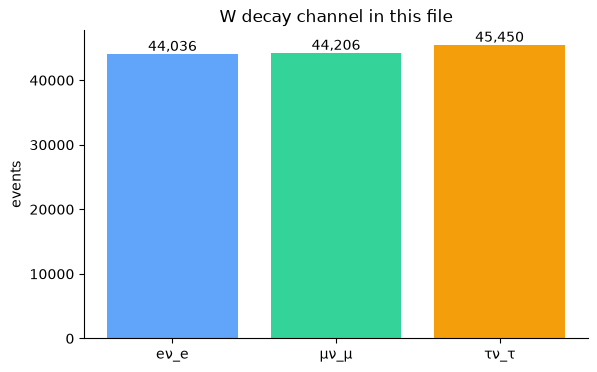

{'eν_e': 44036, 'μν_μ': 44206, 'τν_τ': 45450}

In [23]:
# In LHEPart, status 1 labels particles leaving the primary high-energy interaction.
lhe_final_abs_id = abs(data.LHEPart_pdgId[data.LHEPart_status == 1])
# Each channel mask contains one True/False value per event.
decay_channels = {
    "eν_e": ak.any(lhe_final_abs_id == 11, axis=1),
    "μν_μ": ak.any(lhe_final_abs_id == 13, axis=1),
    "τν_τ": ak.any(lhe_final_abs_id == 15, axis=1),
}
channel_counts = {name: int(ak.sum(mask)) for name, mask in decay_channels.items()}
assert sum(channel_counts.values()) == len(data)
mu_channel = decay_channels["μν_μ"]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(list(channel_counts), list(channel_counts.values()), color=["#60a5fa", "#34d399", "#f59e0b"])
ax.bar_label(bars, fmt="{:,}")
ax.set(ylabel="events", title="W decay channel in this file")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
channel_counts

> **Takeaway:** the three channels occur in roughly equal numbers, as expected from lepton universality: the W interacts in essentially the same way with the electron, muon, and tau families. This file was generated specifically with leptonic W decays; W decays to quarks are not included. We now keep the direct muon channel.

In [24]:
# @title Toolbox: particle names, angular helpers, and truth/reco selections
PARTICLE_NAMES = {
    1: "d", -1: "d̄", 2: "u", -2: "ū", 3: "s", -3: "s̄", 4: "c", -4: "c̄", 5: "b", -5: "b̄", 21: "g",
    11: "e⁻", -11: "e⁺", 12: "νₑ", -12: "ν̄ₑ", 13: "μ⁻", -13: "μ⁺", 14: "νμ", -14: "ν̄μ",
    15: "τ⁻", -15: "τ⁺", 16: "ντ", -16: "ν̄τ", 22: "γ", 23: "Z", 24: "W⁺", -24: "W⁻",
}

def particle_name(pdg_id):
    return PARTICLE_NAMES.get(int(pdg_id), f"PDG {int(pdg_id)}")

def display_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join("---" for _ in headers) + " |"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

def has_flag(flags, bit):
    return (flags & (1 << bit)) != 0

def delta_phi(phi1, phi2):
    return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    return np.hypot(eta1 - eta2, delta_phi(phi1, phi2))

def transverse_mass(pt1, phi1, pt2, phi2):
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi(phi1, phi2))))

# Select the stable hard-process muon and muon-neutrino in every direct-muon event.
gen_abs_id = abs(data.GenPart_pdgId)
stable = data.GenPart_status == 1
from_hard_process = has_flag(data.GenPart_statusFlags, 8)
gen_mu_mask = (gen_abs_id == 13) & stable & from_hard_process
gen_nu_mask = (gen_abs_id == 14) & stable & from_hard_process
assert bool(ak.all(ak.num(data.GenPart_pdgId[gen_mu_mask], axis=1)[mu_channel] == 1))
assert bool(ak.all(ak.num(data.GenPart_pdgId[gen_nu_mask], axis=1)[mu_channel] == 1))

# Muon_genPartIdx points back to a row in the GenPart collection.
gen_mu_index = ak.fill_none(ak.firsts(ak.local_index(data.GenPart_pdgId)[gen_mu_mask]), -999)
matched_reco_muon = data.Muon_genPartIdx == gen_mu_index
matched_reco_count = ak.num(data.Muon_pt[matched_reco_muon], axis=1)
assert int(ak.max(matched_reco_count[mu_channel])) <= 1
has_reco_match = matched_reco_count == 1
analysis_mask = mu_channel & has_reco_match

## 4. One generated $W\to\mu\nu$ event

`GenPart` is the stored generator history after the primary interaction and later decays. The generator may keep several bookkeeping stages of the same W boson; these do **not** represent several physical W bosons. The Toolbox cell selects the final stored W stage and follows its links to the direct decay products.

**Predict first:** Which row in the table should leave signals in CMS? Which should cross the detector with little or no measurable interaction?

The table emphasizes the physics result rather than the bookkeeping. Here $p_T$ is momentum perpendicular to the beams, and $\eta$ describes direction relative to the beam.

<details><summary>How does the Toolbox find the decay?</summary>`pdgId` identifies the particle type, `genPartIdxMother` stores the row number of a particle's parent, and the named `isLastCopy` flag identifies the final stored stage of the W. The official branch name uses the historical term “mother” for parent. The [advanced truth notebook](truth_and_four_momentum_69747.ipynb) examines these row numbers, status flags, and repeated copies in detail.</details>

In [25]:
# @title Toolbox: choose and display one generated W decay
# Choose a simple direct-muon event that also has a reconstructed match.
lhe_final_count = ak.num(lhe_final_abs_id, axis=1)
simple_mu_event = mu_channel & (lhe_final_count == 2)
example_index = int(np.flatnonzero(ak.to_numpy(simple_mu_event & analysis_mask))[0])
example = data[example_index]

# Group the aligned GenPart values, then keep the stored W stages.
event_genpart = ak.zip({
    "index": ak.local_index(example.GenPart_pdgId),
    "pdgId": example.GenPart_pdgId,
    "isLastCopy": has_flag(example.GenPart_statusFlags, 13),
})
w_candidates = event_genpart[abs(event_genpart.pdgId) == 24]

# Select the final stored W stage and its direct decay products.
last_w_candidates = w_candidates[w_candidates.isLastCopy]
assert len(last_w_candidates) == 1
w_index = int(last_w_candidates.index[0])
decay_product_indices = np.flatnonzero(ak.to_numpy(example.GenPart_genPartIdxMother == w_index))

print(f"Entry {example_index}; event {int(example.event)}")
decay_rows = []
for index in [w_index, *decay_product_indices]:
    abs_id = abs(int(example.GenPart_pdgId[index]))
    role = "parent" if index == w_index else "decay product"
    detector_outcome = {
        24: "decays before reaching the detector",
        13: "leaves measurable signals",
        14: "usually passes through unseen",
    }[abs_id]
    decay_rows.append([
        role, particle_name(example.GenPart_pdgId[index]), detector_outcome,
        f"{float(example.GenPart_pt[index]):.2f}", f"{float(example.GenPart_eta[index]):+.2f}",
    ])

display_table(
    ["role", "particle", "what happens in CMS", "pT [GeV]", "η"],
    decay_rows,
)

Entry 5; event 6053858


| role | particle | what happens in CMS | pT [GeV] | η |
| --- | --- | --- | --- | --- |
| parent | W⁺ | decays before reaching the detector | 6.38 | -3.22 |
| decay product | μ⁺ | leaves measurable signals | 27.75 | -0.05 |
| decay product | νμ | usually passes through unseen | 28.44 | -1.73 |

> **Takeaway:** simulation gives us a reference description of the W, muon, and neutrino before detector effects. The muon can leave measurable signals; the neutrino usually cannot. This difference drives the rest of the lesson.

## 5. Does CMS reconstruct the generated muon?

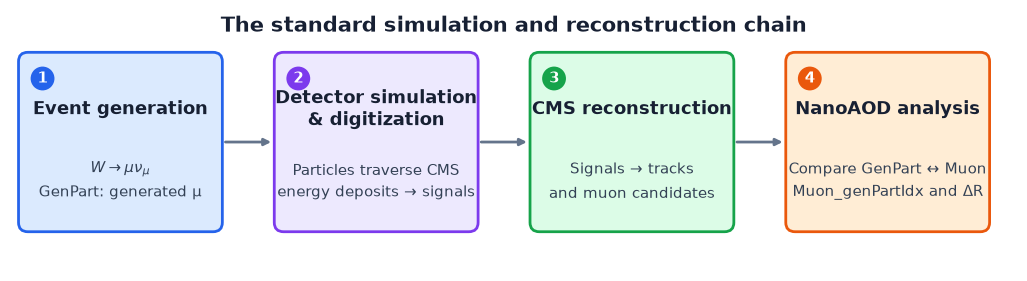

In [26]:
# @title From a generated event to a reconstructed muon
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.set(xlim=(0, 13), ylim=(0, 3.4))
ax.axis("off")

stages = [
    (0.15, "#dbeafe", "#2563eb", "Event generation", r"$W\to\mu\nu_\mu$" + "\nGenPart: generated μ"),
    (3.45, "#ede9fe", "#7c3aed", "Detector simulation\n& digitization", "Particles traverse CMS\nenergy deposits → signals"),
    (6.75, "#dcfce7", "#16a34a", "CMS reconstruction", "Signals → tracks\nand muon candidates"),
    (10.05, "#ffedd5", "#ea580c", "NanoAOD analysis", "Compare GenPart ↔ Muon\nMuon_genPartIdx and ΔR"),
]
box_width, box_height, box_y = 2.55, 2.25, 0.55

for number, (x, fill, edge, title, detail) in enumerate(stages, start=1):
    ax.add_patch(FancyBboxPatch(
        (x, box_y), box_width, box_height,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=fill, edgecolor=edge, linewidth=2,
    ))
    ax.text(x + 0.27, box_y + box_height - 0.30, str(number), ha="center", va="center",
            color="white", fontsize=11, fontweight="bold",
            bbox={"boxstyle": "circle,pad=0.28", "facecolor": edge, "edgecolor": "none"})
    ax.text(x + box_width / 2, box_y + 1.55, title, ha="center", va="center",
            fontsize=13, fontweight="bold", color="#172033")
    ax.text(x + box_width / 2, box_y + 0.62, detail, ha="center", va="center",
            fontsize=11, linespacing=1.5, color="#334155")

for (x, *_), (next_x, *__) in zip(stages[:-1], stages[1:]):
    ax.annotate("", xy=(next_x - 0.08, box_y + box_height / 2),
                xytext=(x + box_width + 0.08, box_y + box_height / 2),
                arrowprops={"arrowstyle": "-|>", "color": "#64748b", "lw": 2,
                            "shrinkA": 0, "shrinkB": 0})

ax.text(6.5, 3.18, "The standard simulation and reconstruction chain",
        ha="center", va="center", fontsize=15, fontweight="bold", color="#172033")
plt.show()

For simulated events, the generator provides a reference description, often called **truth**. CMS then simulates how the generated particles pass through the detector, converts the simulated energy deposits into electronic signals, and applies the same reconstruction algorithms used for real collision data. A muon can leave a curved track in the inner tracking detector and signals in the outer muon detectors; its curvature in the magnetic field helps determine its momentum. NanoAOD retains both selected generator information and reconstructed objects, so we can compare the two. Real collision data do not have a `GenPart` truth record.

The NanoAOD branch `Muon_genPartIdx` is an index into `GenPart` for a reconstructed muon's generator match. We use the stored association first, then calculate

$$\Delta R=\sqrt{(\Delta\eta)^2+(\Delta\phi)^2}$$

as a check of angular agreement. The angle $\phi$ gives direction around the beam axis, while $\eta$ gives direction relative to the beam axis; a small $\Delta R$ means two directions are close in the detector. Here $\Delta\phi$ is wrapped into $[-\pi,\pi]$ because angles differing by almost $2\pi$ point in almost the same direction. The stored index defines the match; $\Delta R$ checks how closely the two matched directions agree.

**Predict first:** For a well-reconstructed muon, where should the $\Delta R$ distribution lie? Where should the ratio $p_T^{reco}/p_T^{truth}$ lie?

All direct muon events with a stored match: 29,433 / 44,206
For truth muons with pT > 15 GeV and |η| < 2.4: 26,043 / 26,079
Median reconstructed / truth pT: 0.9995
Middle 68% of that ratio: 0.9827 to 1.0165


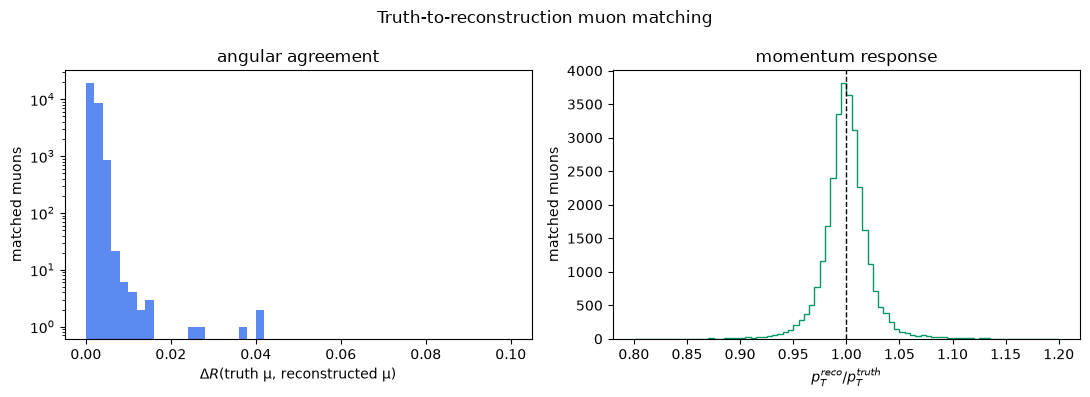

In [27]:
# Reduce the jagged collections to one truth and one matched reconstructed muon per event.
selected = ak.to_numpy(analysis_mask)
gen_mu_pt = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_pt[gen_mu_mask]), np.nan)[selected])
gen_mu_eta = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_eta[gen_mu_mask]), np.nan)[selected])
gen_mu_phi = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_phi[gen_mu_mask]), np.nan)[selected])
reco_mu_pt = ak.to_numpy(ak.fill_none(ak.firsts(data.Muon_pt[matched_reco_muon]), np.nan)[selected])
reco_mu_eta = ak.to_numpy(ak.fill_none(ak.firsts(data.Muon_eta[matched_reco_muon]), np.nan)[selected])
reco_mu_phi = ak.to_numpy(ak.fill_none(ak.firsts(data.Muon_phi[matched_reco_muon]), np.nan)[selected])
assert np.all(np.isfinite([gen_mu_pt, gen_mu_eta, gen_mu_phi, reco_mu_pt, reco_mu_eta, reco_mu_phi]))

# ΔR checks angular agreement; pT(reco)/pT(truth) measures the momentum response.
match_dr = delta_r(reco_mu_eta, reco_mu_phi, gen_mu_eta, gen_mu_phi)
pt_response = reco_mu_pt / gen_mu_pt
response_q16, response_median, response_q84 = np.quantile(pt_response, [0.16, 0.50, 0.84])

# Count matches inside a stated momentum and angular range.
gen_mu_pt_event = ak.firsts(data.GenPart_pt[gen_mu_mask])
gen_mu_eta_event = ak.firsts(data.GenPart_eta[gen_mu_mask])
in_acceptance = mu_channel & (gen_mu_pt_event > 15) & (abs(gen_mu_eta_event) < 2.4)
print(f"All direct muon events with a stored match: {int(ak.sum(analysis_mask)):,} / {int(ak.sum(mu_channel)):,}")
print(f"For truth muons with pT > 15 GeV and |η| < 2.4: {int(ak.sum(in_acceptance & has_reco_match)):,} / {int(ak.sum(in_acceptance)):,}")
print(f"Median reconstructed / truth pT: {response_median:.4f}")
print(f"Middle 68% of that ratio: {response_q16:.4f} to {response_q84:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(match_dr, bins=np.linspace(0, 0.10, 51), color="#2563eb", histtype="stepfilled", alpha=0.75)
axes[0].set(xlabel="$\Delta R$(truth μ, reconstructed μ)", ylabel="matched muons", yscale="log", title="angular agreement")
axes[1].hist(pt_response, bins=np.linspace(0.8, 1.2, 81), color="#059669", histtype="step")
axes[1].axvline(1, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="$p_T^{reco}/p_T^{truth}$", ylabel="matched muons", title="momentum response")
fig.suptitle("Truth-to-reconstruction muon matching")
fig.tight_layout()
plt.show()

> **Takeaway:** the left plot is concentrated near $\Delta R=0$, so the paired directions agree. The right plot is concentrated near a ratio of 1, so the reconstructed momentum is approximately correct on average. Its width shows the event-to-event spread. Notice that the left vertical axis is logarithmic: equal vertical steps represent multiplying the number of events rather than adding the same number.

A missing stored match does not necessarily mean that CMS failed to detect the muon. The muon may be outside the stated angular range, have too little $p_T$, or fail a NanoAOD storage requirement. For truth muons with $p_T>15$ GeV and $|\eta|<2.4$, almost every event in this file has a stored match. This simple count is not a complete measurement of detector performance.

From here on, “selected events” means direct $W\to\mu\nu$ events with one stored generator-matched muon.

<details><summary>How would a full CMS analysis differ?</summary>A real analysis cannot match reconstructed objects to generator truth. It applies requirements designed to select well-measured, collision-produced muons and uses the online trigger system that recorded the events. We omit those additional choices here so the truth-to-reconstruction comparison remains the focus.</details>

## 6. How an invisible neutrino leads to missing transverse momentum

Momentum has components $(p_x,p_y,p_z)$. The $z$ direction follows the proton beams, while $x$ and $y$ span the **transverse plane**, perpendicular to the beams. The transverse momentum and its direction in this plane are

$$p_T=\sqrt{p_x^2+p_y^2},\qquad \phi=\text{angle around the beam axis}.$$

The incoming protons have essentially zero total momentum in this plane. The partons inside them carry unknown fractions of the protons' longitudinal momentum, so transverse momentum balance is especially useful at the LHC.

Because neutrinos interact only weakly, a neutrino usually passes through CMS without depositing measurable energy. The detector instead infers the missing transverse-momentum vector

$$\vec p_T^{\,miss}\simeq-\sum_{\mathrm{reconstructed\ particles}}\vec p_T.$$

NanoAOD uses the historical name `MET` (“missing transverse energy”) for reconstructed missing transverse momentum. We will compare three related quantities:

| Quantity | Meaning |
| --- | --- |
| W neutrino | The one neutrino produced in the generated W decay |
| `GenMET` | The ideal event-wide missing transverse momentum calculated from generated particles |
| `MET` | The event-wide momentum imbalance inferred from reconstructed detector information |

`GenMET` is usually almost identical to the W neutrino in this sample, but it describes the whole event rather than pointing to one particle. The actual CMS `MET` calculation includes detector-wide reconstruction and calibration details; the equation above states the vector-balance idea.

**Predict first:** Which two quantities in the table should agree most closely? Why should reconstructed `MET` have a larger event-to-event spread?

In the one-event plot below, the truth and reconstructed muon vectors are so similar that their lines nearly overlap. Endpoint circles denote truth and crosses denote reconstruction, so both remain visible without shifting either vector.

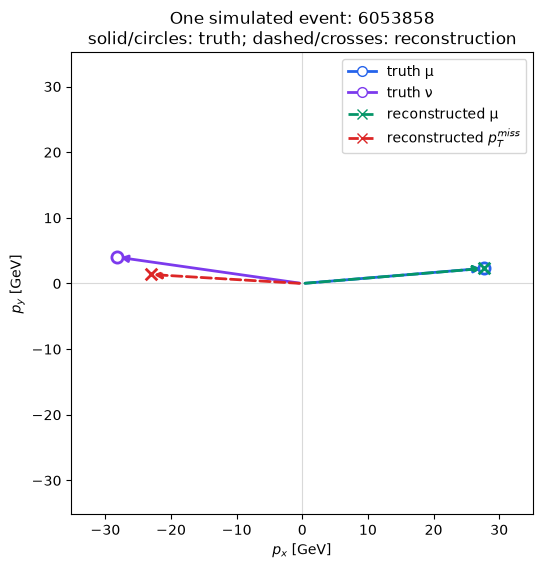

In [28]:
# Compare generator and reconstructed transverse vectors in the same event.
vector_event = example_index
event_gen_mu_pt = float(ak.firsts(data.GenPart_pt[gen_mu_mask])[vector_event])
event_gen_mu_phi = float(ak.firsts(data.GenPart_phi[gen_mu_mask])[vector_event])
event_gen_nu_pt = float(ak.firsts(data.GenPart_pt[gen_nu_mask])[vector_event])
event_gen_nu_phi = float(ak.firsts(data.GenPart_phi[gen_nu_mask])[vector_event])
event_reco_mu_pt = float(ak.firsts(data.Muon_pt[matched_reco_muon])[vector_event])
event_reco_mu_phi = float(ak.firsts(data.Muon_phi[matched_reco_muon])[vector_event])

vectors = [
    ("truth μ", event_gen_mu_pt, event_gen_mu_phi, "#2563eb", "-", "o"),
    ("truth ν", event_gen_nu_pt, event_gen_nu_phi, "#7c3aed", "-", "o"),
    ("reconstructed μ", event_reco_mu_pt, event_reco_mu_phi, "#059669", "--", "x"),
    ("reconstructed $p_T^{miss}$", float(data.MET_pt[vector_event]), float(data.MET_phi[vector_event]), "#dc2626", "--", "x"),
]
fig, ax = plt.subplots(figsize=(6, 6))
components = []
# Convert (pT, φ) to Cartesian components for plotting.
for label, pt_value, phi_value, color, line_style, marker in vectors:
    px_value, py_value = pt_value * np.cos(phi_value), pt_value * np.sin(phi_value)
    components.extend([abs(px_value), abs(py_value)])
    ax.annotate(
        "", xy=(px_value, py_value), xytext=(0, 0),
        arrowprops={"arrowstyle": "-|>", "color": color, "lw": 2, "linestyle": line_style},
    )
    if marker == "o":
        ax.scatter(px_value, py_value, marker=marker, s=65, facecolors="white", edgecolors=color, linewidths=2, zorder=5)
    else:
        ax.scatter(px_value, py_value, marker=marker, s=70, color=color, linewidths=2, zorder=6)
    ax.plot(
        [], [], color=color, linestyle=line_style, linewidth=2, marker=marker,
        markerfacecolor="white" if marker == "o" else color, markeredgecolor=color,
        markersize=7, label=label,
    )
limit = 1.25 * max(components)
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel="$p_x$ [GeV]", ylabel="$p_y$ [GeV]")
ax.axhline(0, color="0.85", linewidth=0.8); ax.axvline(0, color="0.85", linewidth=0.8)
ax.set_aspect("equal"); ax.legend(); ax.set_title(
    f"One simulated event: {int(data.event[vector_event])}\n"
    "solid/circles: truth; dashed/crosses: reconstruction"
)
plt.show()

### Making momentum conservation visible

The incoming protons travel along the $z$ direction, so the total transverse momentum before the collision is approximately zero. This does **not** mean that the muon and neutrino must cancel each other. The collision produces a W together with other activity: quarks and gluons can radiate additional particles, which may appear as jets or softer signals in the detector. If the W moves sideways in one direction, that other activity must collectively move in the opposite direction.

We call the combined transverse momentum of everything recoiling against the W the **recoil**, $\vec u_T$. It is not one additional particle; it is a bookkeeping name for the vector sum of the rest of the event. It is similar to people standing on frictionless ice: if one person moves in one direction, the others must carry momentum in the opposite direction.

After the W decays, its momentum is shared by the muon and neutrino. Momentum conservation therefore gives

$$\vec p_T^W=\vec p_T^\mu+\vec p_T^\nu,\qquad
\vec p_T^\mu+\vec p_T^\nu+\vec u_T^{\,truth}\simeq\vec 0.$$

At truth level, the recoil points opposite to the stored W: $\vec u_T^{\,truth}=-\vec p_T^W$. At reconstruction level, `MET` already uses all reconstructed objects, so the recoil excluding the muon is $\vec u_T^{\,reco}=-(\vec p_T^\mu+\vec p_T^{\,miss})$.

The arrows above all start at the origin, which is useful for comparing their directions but not for seeing how vectors add. In the next plot, each arrow starts where the previous one ends. A path that returns to the origin has zero total transverse momentum. The tiny truth-level gap comes from the limited numerical precision used to store NanoAOD values.

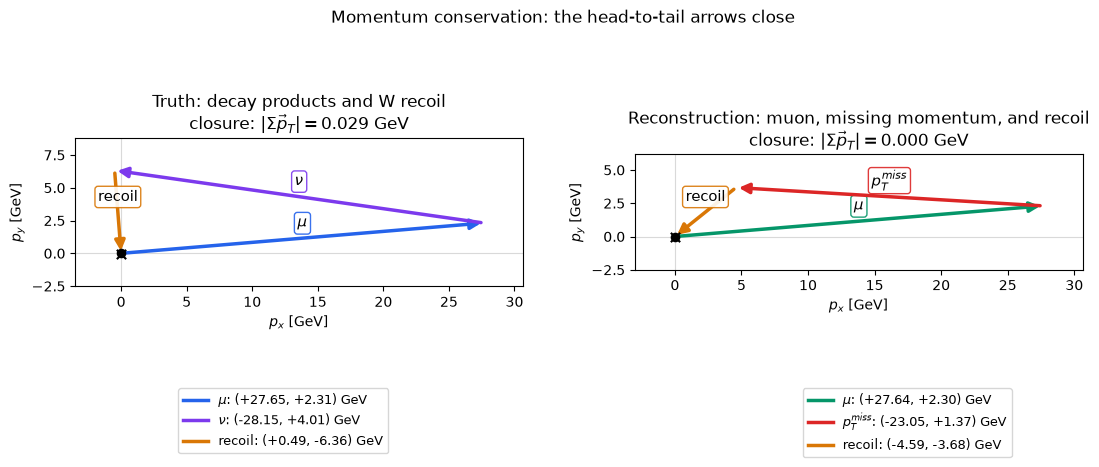

In [29]:
# Add transverse-momentum vectors head-to-tail to display event balance.
def transverse_components(pt_value, phi_value):
    return np.array([pt_value * np.cos(phi_value), pt_value * np.sin(phi_value)])

truth_mu_xy = transverse_components(event_gen_mu_pt, event_gen_mu_phi)
truth_nu_xy = transverse_components(event_gen_nu_pt, event_gen_nu_phi)
truth_w_xy = transverse_components(
    float(example.GenPart_pt[w_index]), float(example.GenPart_phi[w_index])
)
truth_recoil_xy = -truth_w_xy

reco_mu_xy = transverse_components(event_reco_mu_pt, event_reco_mu_phi)
reco_met_xy = transverse_components(
    float(data.MET_pt[vector_event]), float(data.MET_phi[vector_event])
)
reco_recoil_xy = -(reco_mu_xy + reco_met_xy)

closure_panels = [
    (
        "Truth: decay products and W recoil",
        [(r"$\mu$", truth_mu_xy, "#2563eb"),
         (r"$\nu$", truth_nu_xy, "#7c3aed"),
         ("recoil", truth_recoil_xy, "#d97706")],
    ),
    (
        "Reconstruction: muon, missing momentum, and recoil",
        [(r"$\mu$", reco_mu_xy, "#059669"),
         (r"$p_T^{miss}$", reco_met_xy, "#dc2626"),
         ("recoil", reco_recoil_xy, "#d97706")],
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
legend_centers = [0.285, 0.765]
for panel_index, (ax, (title, panel_vectors)) in enumerate(zip(axes, closure_panels)):
    position = np.zeros(2)
    path = [position.copy()]
    for label, vector_xy, color in panel_vectors:
        next_position = position + vector_xy
        ax.annotate(
            "", xy=next_position, xytext=position,
            arrowprops={"arrowstyle": "-|>", "color": color, "lw": 2.5,
                        "mutation_scale": 15},
        )
        midpoint = (position + next_position) / 2
        ax.annotate(
            label, xy=midpoint, xytext=(0, 8), textcoords="offset points",
            ha="center", fontsize=11,
            bbox={"boxstyle": "round,pad=0.2", "facecolor": "white",
                  "edgecolor": color, "alpha": 0.9},
        )
        ax.plot([], [], color=color, linewidth=2.5,
                label=f"{label}: ({vector_xy[0]:+.2f}, {vector_xy[1]:+.2f}) GeV")
        position = next_position
        path.append(position.copy())

    path = np.asarray(path)
    closure_size = np.hypot(*position)
    x_padding, y_padding = 3.0, 2.5
    ax.set(
        xlim=(path[:, 0].min() - x_padding, path[:, 0].max() + x_padding),
        ylim=(path[:, 1].min() - y_padding, path[:, 1].max() + y_padding),
        xlabel="$p_x$ [GeV]", ylabel="$p_y$ [GeV]",
    )
    ax.axhline(0, color="0.85", linewidth=0.8)
    ax.axvline(0, color="0.85", linewidth=0.8)
    ax.scatter(0, 0, color="black", s=35, zorder=5)
    ax.scatter(*position, color="black", marker="x", s=45, zorder=6)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title + "\n" + rf"closure: $|\Sigma\vec p_T|={closure_size:.3f}$ GeV")
    ax.legend(
        loc="upper center", bbox_to_anchor=(legend_centers[panel_index], 0.17),
        bbox_transform=fig.transFigure, fontsize=9,
    )

fig.suptitle("Momentum conservation: the head-to-tail arrows close")
fig.subplots_adjust(top=0.77, bottom=0.31, wspace=0.25)
plt.show()

> **How to read the closure:** the truth arrows return almost exactly to the origin, showing that the W momentum carried by the muon and neutrino is balanced by the recoil. The reconstructed arrows close exactly because the reconstructed recoil is defined from the muon and event-wide `MET`. This checks the vector bookkeeping; it does not mean that `MET` measures the neutrino perfectly.

Median GenMET / W-neutrino pT: 1.000
Median |Δφ|(GenMET, W neutrino): 0.0010 rad


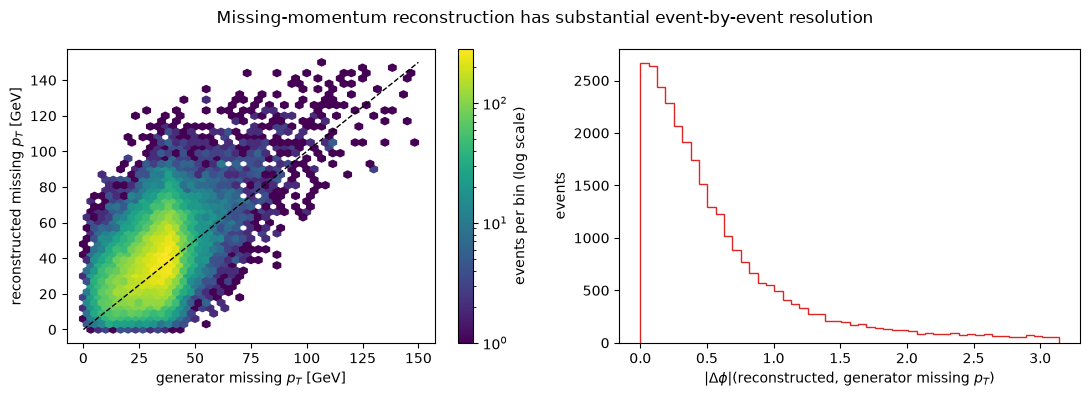

In [11]:
# Extract one hard-process neutrino and the two event-level missing-momentum definitions.
gen_nu_pt = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_pt[gen_nu_mask]), np.nan)[selected])
gen_nu_eta = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_eta[gen_nu_mask]), np.nan)[selected])
gen_nu_phi = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_phi[gen_nu_mask]), np.nan)[selected])
gen_nu_mass = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_mass[gen_nu_mask]), np.nan)[selected])
gen_mu_mass = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_mass[gen_mu_mask]), np.nan)[selected])
genmet_pt = ak.to_numpy(data.GenMET_pt[selected])
genmet_phi = ak.to_numpy(data.GenMET_phi[selected])
met_pt = ak.to_numpy(data.MET_pt[selected])
met_phi = ak.to_numpy(data.MET_phi[selected])
assert np.all(np.isfinite([gen_nu_pt, gen_nu_eta, gen_nu_phi, gen_nu_mass, gen_mu_mass, genmet_pt, genmet_phi, met_pt, met_phi]))

print(f"Median GenMET / W-neutrino pT: {np.median(genmet_pt / gen_nu_pt):.3f}")
print(f"Median |Δφ|(GenMET, W neutrino): {np.median(abs(delta_phi(genmet_phi, gen_nu_phi))):.4f} rad")

# Compare reconstructed MET with generator-level missing momentum, not just one particle.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hb = axes[0].hexbin(genmet_pt, met_pt, extent=(0, 150, 0, 150), gridsize=45, bins="log", mincnt=1)
axes[0].plot([0, 150], [0, 150], "k--", linewidth=1)
axes[0].set(xlabel="generator missing $p_T$ [GeV]", ylabel="reconstructed missing $p_T$ [GeV]")
fig.colorbar(hb, ax=axes[0], label="events per bin (log scale)")
axes[1].hist(abs(delta_phi(met_phi, genmet_phi)), bins=np.linspace(0, np.pi, 51), histtype="step", color="#dc2626")
axes[1].set(xlabel="$|\Delta\phi|$(reconstructed, generator missing $p_T$)", ylabel="events")
fig.suptitle("Missing-momentum reconstruction has substantial event-by-event resolution")
fig.tight_layout()
plt.show()

> **How to read the plots:** in the left plot, the dashed diagonal marks perfect agreement between generated and reconstructed missing momentum. Each colored region groups events with similar values, and its color represents the number of events on a logarithmic scale. In the right plot, values near zero mean that the generated and reconstructed vectors point in similar directions. The visible spread in both plots shows that `MET` is not an exact measurement of the neutrino.

> **Takeaway:** missing momentum is a detector-wide balance measurement. Calling it “the neutrino momentum” is often a useful approximation, but not its definition.

**Check your reasoning:** If CMS measured every visible particle perfectly and the W neutrino were the only invisible particle, what relationship would you expect between the neutrino's transverse momentum and $\vec p_T^{\,miss}$?

## 7. The missing longitudinal component

In relativity, energy and momentum are combined into an **energy–momentum four-vector**

$$P=(E,\vec p)=(E,p_x,p_y,p_z).$$

Particle physicists often choose units in which the speed of light $c=1$. In these units, energy, momentum, and mass can all be quoted in GeV; this shortens expressions that would otherwise contain factors of $c$.

Four-vectors can be added. The **invariant mass** of the combined system—its mass independent of the observer's motion—is

$$m^2=E^2-p_x^2-p_y^2-p_z^2.$$

Reconstructing the W invariant mass therefore requires all components of both decay products. Generator truth supplies the neutrino's $\eta$, so we can calculate $p_z^\nu$ and the full $\mu\nu$ invariant mass. Reconstructed missing momentum contains only $p_T$ and $\phi$.

The contrast with section 6 is crucial: the initial total transverse momentum is approximately known to be zero, but the initial longitudinal momentum is unknown because the two colliding partons carry different, unknown fractions of the proton momenta. Longitudinal momentum conservation therefore cannot determine $p_z^\nu$ event by event.

<details><summary>What exactly is the “truth mass” here?</summary>It is the invariant mass built from the stable hard-interaction muon and neutrino stored in `GenPart`. Photons radiated by the muon are not added back.</details>

We must not quietly set $p_z^\nu=0$. Instead, treating the muon and neutrino as nearly massless, we use only measured transverse quantities to form the **transverse mass**

$$m_T=\sqrt{2p_T^\mu p_T^{miss}\left(1-\cos\Delta\phi\right)}.$$

The formula has useful limiting cases. If the two transverse vectors point together, $\Delta\phi=0$ and $m_T=0$. If they point in opposite directions, $\Delta\phi=\pi$ and $m_T$ is as large as it can be for those two $p_T$ values.

**Predict first:** The full truth invariant mass should cluster near the W mass, about 80 GeV. What shape do you expect when the unknown longitudinal information is removed?

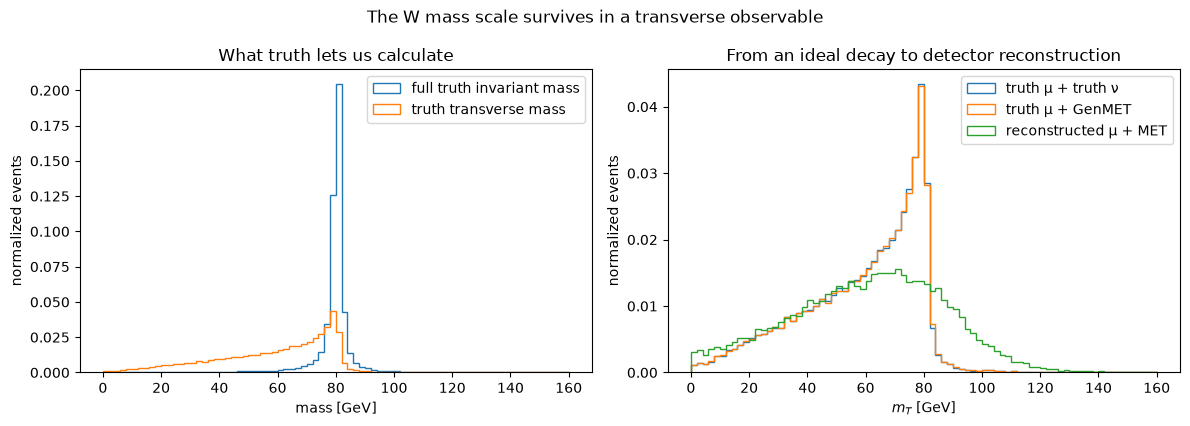

In [12]:
# Build (E, px, py, pz) from NanoAOD's (pT, η, φ, mass) coordinates.
def four_vector(pt, eta, phi, mass):
    return np.column_stack([
        np.sqrt((pt * np.cosh(eta))**2 + mass**2),
        pt * np.cos(phi), pt * np.sin(phi), pt * np.sinh(eta),
    ])

mu_p4 = four_vector(gen_mu_pt, gen_mu_eta, gen_mu_phi, gen_mu_mass)
nu_p4 = four_vector(gen_nu_pt, gen_nu_eta, gen_nu_phi, gen_nu_mass)
truth_total = mu_p4 + nu_p4
truth_mass_squared = truth_total[:, 0]**2 - np.sum(truth_total[:, 1:]**2, axis=1)
truth_invariant_mass = np.sqrt(np.maximum(truth_mass_squared, 0))

# Replace the truth neutrino step by step with GenMET and reconstructed MET.
truth_mt = transverse_mass(gen_mu_pt, gen_mu_phi, gen_nu_pt, gen_nu_phi)
gen_observable_mt = transverse_mass(gen_mu_pt, gen_mu_phi, genmet_pt, genmet_phi)
reco_mt = transverse_mass(reco_mu_pt, reco_mu_phi, met_pt, met_phi)

bins = np.linspace(0, 160, 81)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].hist(truth_invariant_mass, bins=bins, histtype="step", density=True, label="full truth invariant mass")
axes[0].hist(truth_mt, bins=bins, histtype="step", density=True, label="truth transverse mass")
axes[0].set(xlabel="mass [GeV]", ylabel="normalized events", title="What truth lets us calculate")
axes[0].legend()

axes[1].hist(truth_mt, bins=bins, histtype="step", density=True, label="truth μ + truth ν")
axes[1].hist(gen_observable_mt, bins=bins, histtype="step", density=True, label="truth μ + GenMET")
axes[1].hist(reco_mt, bins=bins, histtype="step", density=True, label="reconstructed μ + MET")
axes[1].set(xlabel="$m_T$ [GeV]", ylabel="normalized events", title="From an ideal decay to detector reconstruction")
axes[1].legend()
fig.suptitle("The W mass scale survives in a transverse observable")
fig.tight_layout()
plt.show()

### How to read the final plots

All curves are normalized to the same total area, so compare their shapes rather than their total event counts.

- **Left panel:** the full truth invariant mass forms a narrow peak near 80 GeV. The truth transverse mass spreads below that scale and forms an **edge**: many different decays fall below the parent mass once the longitudinal information is discarded.
- **Right panel:** the three curves replace ideal information one step at a time. The first uses the generated muon and W neutrino, the second uses the event-wide generated missing momentum, and the third uses reconstructed detector quantities. Their increasing differences show the effects of the rest of the event and detector reconstruction.
- An ideal two-body decay has $m_T$ no larger than that event's W invariant mass. The W is unstable, so generated W masses have a small physical spread, and detector-wide missing-momentum reconstruction adds further smearing. The reconstructed distribution therefore does not end at one perfectly sharp value.

The important distinction is **peak versus edge**: full invariant mass can gather near the parent mass, while transverse mass is distributed below a limiting scale because it deliberately omits the unknown longitudinal momentum.

## 8. Takeaways

- Simulation truth tells us what was generated; reconstruction tells us what the detector inferred.
- A neutrino is not measured directly. Its presence is inferred through transverse momentum imbalance.
- Energy and three momentum components form a four-vector; $p_T$ is the momentum projected perpendicular to the beams.
- At a proton collider, the unknown incoming parton momenta make transverse observables especially useful.
- The truth $\mu\nu$ invariant mass clusters near the W mass. The transverse mass retains a characteristic edge near the W mass scale without assuming a neutrino $p_z$.
- Because the W is unstable, its generated mass has a small physical spread. Other invisible particles and imperfect detector reconstruction blur the ideal transverse-mass edge further.

## Check your understanding

These questions require no programming.

1. For the generated muon, generated neutrino, reconstructed muon, and reconstructed missing momentum, which are particle descriptions and which are detector inferences?
2. Why can we begin transverse momentum balance with approximately zero, but not do the same for longitudinal momentum?
3. Suppose $p_T^\mu=40$ GeV, $p_T^{miss}=40$ GeV, and the two vectors are opposite. Calculate $m_T$. What happens if the vectors instead point in the same direction?
4. In the final plots, what visual evidence shows that detector reconstruction is useful but not perfect?

<details><summary>Answers</summary>

1. The generated muon and neutrino are particle descriptions from simulation. The reconstructed muon and missing momentum are inferences from simulated detector signals; missing momentum is an event-wide vector, not a reconstructed neutrino.
2. The beams supply essentially no initial transverse momentum, but the two colliding partons carry unknown and generally unequal longitudinal momenta.
3. For opposite vectors, $\Delta\phi=\pi$ and $m_T=\sqrt{2(40)(40)(2)}=80$ GeV. For parallel vectors, $\Delta\phi=0$ and $m_T=0$.
4. The reconstructed quantities follow the same overall scales and trends as truth, but their distributions have visible event-to-event spread and do not lie perfectly on the ideal expectations.

</details>

## Optional coding extensions

1. Rewrite `delta_phi` and `transverse_mass` without looking at the Toolbox. Explain why an angular difference must be wrapped around $2\pi$.
2. Plot the fraction of truth muons with a stored match versus truth $p_T$ and $\eta$. State clearly that this is a stored-match fraction, not a complete detector-efficiency measurement.
3. Study missing-momentum agreement versus the number of reconstructed jets (`nJet`) or the simulated amount of additional proton collisions (`Pileup_nTrueInt`).
4. Select $W\to\tau\nu$ followed by $\tau\to\mu\nu\nu$. Explain why several neutrinos make the missing-momentum interpretation more complicated.

For generator-copy bookkeeping, four-momentum closure, decay trees, and the optional neutrino-$p_z$ calculation, continue with the [advanced truth and four-momentum notebook](truth_and_four_momentum_69747.ipynb).